## Data Used
1. 2015-12 USArray Manual picks
2. 2015-12 Usarray original earthquake data.

## Findings 1
In 17773983 indexed usarray documents, only 3k have manual picks.

Breakdown:

manual_picks length = 3: 10 docs
manual_picks length = 2: 94 docs
manual_picks length = 1: 3224 docs
manual_picks length = 0: 17770655 docs

## Finding 2
The 3224 docs that have one manual pick can be grouped into 16 valid streams (with Z, N and E)

## Finding 3
Over 16 streams, 6 has p wave arrival pick confidence over 0.1
Over 16 streams, 2 has p wave arrival pick confidence over 0.5
Over 16 streams, 1 has p wave arrival pick confidence over 0.6

## Finding 4
For the prediction with the highest confidence, after plot, the predicted pick is close to the manual pick.

Refer to the last plot of the notebook

## Conclusion

The pretrained PhaseNet model shows promise on the limited USArray sample, but the evidence is sparse—just 16 streams.

To gauge its true performance, we need to run it on a much larger portion of the dataset.

In [2]:
import numpy
import pandas as pd
from mspasspy.preprocessing.css30.datascope import DatascopeDatabase

# Section 1. Index USArray in mongo and match with manual picks

In [3]:
fname = 'manual_picks/events_usarray_2015_12/usarray_2015_12.arrival'

In [4]:
widths=[7,18,9,9,9,9,9,9,1+6+7+7+7+7+7+10+7+7+1+2+10+1+15+8+17]
keys=['sta','time','arid','jdate','stassid','chanid','chan','iphase','debris']
df = pd.read_fwf(fname,names=keys,widths=widths)
print('Number of rows in DataFrame created from arrival = ',len(df))

Number of rows in DataFrame created from arrival =  21573


In [5]:
df

,sta,time,arid,jdate,stassid,chanid,chan,iphase,debris
0,CUT,1.448943e+09,16164217,2015335,-1,437,BHZ,P,- 0.225 -1.00 -1.00 -1.00 -1.00 -1....
1,TRF,1.448943e+09,16164218,-1,-1,5715,BHZ,P,- 0.064 -1.00 -1.00 -1.00 -1.00 -1....
2,WAT1,1.448943e+09,16164219,-1,-1,1836,HHZ,P,- 0.038 -1.00 -1.00 -1.00 -1.00 -1....
3,MCK,1.448943e+09,16164220,2015335,-1,904,BHZ,P,- 0.160 -1.00 -1.00 -1.00 -1.00 -1....
4,WAT6,1.448943e+09,16164221,-1,-1,1888,BHZ,P,- 0.051 -1.00 -1.00 -1.00 -1.00 -1....
...,...,...,...,...,...,...,...,...,...
21568,PAL,1.451601e+09,16185785,-1,-1,7522,BHZ,P,- -1.000 -1.00 -1.00 -1.00 -1.00 -1....
21569,HRV,1.451601e+09,16185786,-1,-1,7434,BHZ_10,P,- -1.000 -1.00 -1.00 -1.00 -1.00 -1....
21570,GOGA,1.451601e+09,16185787,-1,-1,8079,BHZ_00,P,- -1.000 -1.00 -1.00 -1.00 -1.00 -1....
21571,KMSC,1.451601e+09,16185788,2015365,-1,37305,BHZ,P,- 0.248 -1.00 -1.00 -1.00 -1.00 -1....


In [6]:
# 1. use datascope.get_table to load the manual picks
dbname = "manual_picks/events_usarray_2015_12/usarray_2015_12"
pffile = "data/pf/DatascopeDatabase.pf"
dsd = DatascopeDatabase(dbname, pffile=pffile)

In [7]:
mp_df = dsd.get_table("arrival")
# only need sta, time -> arrival time

In [8]:
len(mp_df)

21573

In [9]:
# 2. CSS30Catalog2df() associates the picks with earth quake info
arrival_df = dsd.CSS30Catalog2df()
arrival_df.head()

,evid,evname,prefor,auth,commid,lddate,lat,lon,depth,time,...,amp,per,logat,clip,fm,snr,qual,auth_arrival,commid_arrival,lddate_arrival
0,187921,-,309754,AK:natasha,-1,1.455902e+09,62.9638,-149.8953,79.9000,1.448943e+09,...,-1.0,-1.0,-999.0,-,-,6.6401,-,dbp:vladik:1533,-1,1.448981e+09
1,187921,-,309754,AK:natasha,-1,1.455902e+09,62.9861,-149.8631,81.4174,1.448943e+09,...,-1.0,-1.0,-999.0,-,-,6.6401,-,dbp:vladik:1533,-1,1.448981e+09
2,187921,-,309754,AK:natasha,-1,1.455902e+09,62.9638,-149.8954,79.8699,1.448943e+09,...,-1.0,-1.0,-999.0,-,-,6.6401,-,dbp:vladik:1533,-1,1.448981e+09
3,187921,-,309754,AK:natasha,-1,1.455902e+09,62.9638,-149.8953,79.9000,1.448943e+09,...,-1.0,-1.0,-999.0,-,-,-1.0000,-,dbp:vladik:1533,-1,1.448981e+09
4,187921,-,309754,AK:natasha,-1,1.455902e+09,62.9861,-149.8631,81.4174,1.448943e+09,...,-1.0,-1.0,-999.0,-,-,-1.0000,-,dbp:vladik:1533,-1,1.448981e+09


In [10]:
# 3. use sta to match wf data
# use time to get the closest window (start and end), ideally one window for one arrival, could be multiple windows
#    - simple case
#    - multiple match cases: phase net pick vs manual picks < 5s

# build index on sta time for the matching
# match (2s, or ?s), time diff

In [13]:
from mspasspy.db.client import DBClient
from mspasspy.db.database import Database
from mspasspy.ccore.utility import MsPASSError,ErrorSeverity
from bson.codec_options import CodecOptions
import os
import fnmatch
dbclient=DBClient("c206-006:27020")
db = dbclient.get_database("usarray2015")

In [14]:
db.list_collection_names()

['wf_miniseed']

In [15]:
import os
import fnmatch
all_selected_files = []
dir = '/scratch1/07114/jiaoma/usarray_2015/2015'
file_list = fnmatch.filter(os.listdir(dir), '*.mseed')
all_selected_files.extend([os.path.join(dir, f) for f in file_list])
len(all_selected_files) 

901

In [16]:
all_selected_files[:10]

['/scratch1/07114/jiaoma/usarray_2015/2015/event49.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event197.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event217.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event192.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event768.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event96.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event440.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event111.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event709.mseed',
 '/scratch1/07114/jiaoma/usarray_2015/2015/event418.mseed']

In [17]:
all_selected_files.index("/scratch1/07114/jiaoma/usarray_2015/2015/event759.mseed")

239

In [18]:
# NOTE there are 900 files, currently it indexed ~300 files
from time import time
from mspasspy.db.database import index_mseed_file_parallel
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm
import threading

# parallel processing is even slower than sequential processing, maybe it is bounded by mongo db core
# total_files = len(all_selected_files)

# # Thread-safe progress counter
# progress_counter = 0
# counter_lock = threading.Lock()

# def index_with_progress(db, file_path, dir, total_files, starttime):
#     global progress_counter

#     # Call the original function
#     index_mseed_file_parallel(db, file_path, dir)

#     # Update progress
#     with counter_lock:
#         time_elapsed = time() - starttime
#         progress_counter += 1
#         print(f"[{progress_counter}/{total_files}] Indexed: {file_path}, seconds elapsed: {time_elapsed}")

# with ThreadPoolExecutor(max_workers=8) as executor:
#     starttime = time()
#     for file_path in all_selected_files:
#         executor.submit(index_with_progress, db, file_path, dir, total_files, starttime)

In [17]:
# total_time = 0
# file_counter = 0

# for dfile in all_selected_files:
#     t0 = time()
#     db.index_mseed_file(dfile, dir)
#     t1 = time()
#     dt = t1 - t0
#     total_time += dt
#     # print('Time to index file=', dfile, ' = ', dt)

#     file_counter += 1
#     if file_counter % 10 == 0:
#         print('Current count: {}, time elapsed: {:.2f}s, file: {}'.format(file_counter, total_time, dfile))

In [18]:
# from obspy import read
# import warnings
# warnings.filterwarnings('ignore')

# total_tr = 0
# is_15_12_tr = 0
# for f in all_selected_files[:500]:
#     try:
#         st = read(f)
#     except Exception:
#         continue
#     for tr in st:
#         total_tr += 1
#         if tr.stats.starttime.year == 2015 and tr.stats.starttime.month == 12:
#             is_15_12_tr += 1
# print("Total trace: {}, 2015-12 trace: {}".format(total_tr, is_15_12_tr))

# Total trace: 171572, 2015-12 trace: 7190

In [19]:
# db.wf_miniseed.count_documents({})

In [19]:
db.wf_miniseed.find_one()

{'_id': ObjectId('67fd20a3b81efdb2a8472074'),
 'sta': 'WB01',
 'net': '6E',
 'chan': 'BHE',
 'sampling_rate': 40.0,
 'delta': 0.025,
 'starttime': 1448894724.355,
 'last_packet_time': 1448894857.5049999,
 'foff': 0,
 'nbytes': 12288,
 'npts': 8639,
 'endtime': 1448894940.305,
 'storage_mode': 'file',
 'format': 'mseed',
 'dir': '/scratch1/07114/jiaoma/usarray_2015/2015',
 'dfile': '/scratch1/07114/jiaoma/usarray_2015/2015/event49.mseed',
 'time_standard': 'UTC'}

In [20]:
# query={'sta': {'$eq': 'WB01'}, 'starttime' : {'$eq' : 1448894724.355}, 'endtime' : {'$eq' : 1448894940.305},
#        'dfile': {'$eq': '/scratch1/07114/jiaoma/usarray_2015/2015/event49.mseed'}}
# db.wf_miniseed.count_documents(query)

In [21]:
# index details of the collection
for index in db.wf_miniseed.list_indexes():
    print(f"Index Name: {index['name']}")
    print(f" - Keys: {index['key']}")
    print(f" - Unique: {index.get('unique', False)}")
    print(f" - Sparse: {index.get('sparse', False)}")
    print(f" - TTL: {index.get('expireAfterSeconds')}")

Index Name: _id_
 - Keys: SON([('_id', 1)])
 - Unique: False
 - Sparse: False
 - TTL: None
Index Name: sta_1
 - Keys: SON([('sta', 1)])
 - Unique: False
 - Sparse: False
 - TTL: None
Index Name: starttime_1_endtime_1
 - Keys: SON([('starttime', 1), ('endtime', 1)])
 - Unique: False
 - Sparse: False
 - TTL: None


In [23]:
# db.wf_miniseed.create_index("sta")

In [24]:
# db.wf_miniseed.create_index(['starttime', 'endtime'])

In [25]:
# db.wf_miniseed.create_index("chan_1")

In [26]:
# # find documents that have channel as %Z, Z (vertical) is most important for p-wave pick
# query={'chan': {'$regex': 'Z$'}}
# n=db.wf_miniseed.count_documents(query)
# print('Number of documents that have chan as %Z = ',n)

In [23]:
# head of manual pick data frame
mp_df.head()

,sta,time,arid,jdate,stassid,chanid,chan,iphase,stype,deltim,...,amp,per,logat,clip,fm,snr,qual,auth,commid,lddate
0,CUT,1.448943e+09,16164217,2015335,-1,437,BHZ,P,-,0.225,...,-1.0,-1.0,-999.0,-,-,6.6401,-,dbp:vladik:1533,-1,1.448981e+09
1,TRF,1.448943e+09,16164218,-1,-1,5715,BHZ,P,-,0.064,...,-1.0,-1.0,-999.0,-,-,-1.0000,-,dbp:vladik:1533,-1,1.448981e+09
2,WAT1,1.448943e+09,16164219,-1,-1,1836,HHZ,P,-,0.038,...,-1.0,-1.0,-999.0,-,-,-1.0000,-,dbp:vladik:1533,-1,1.448981e+09
3,MCK,1.448943e+09,16164220,2015335,-1,904,BHZ,P,-,0.160,...,-1.0,-1.0,-999.0,-,-,6.9258,-,dbp:vladik:1533,-1,1.448981e+09
4,WAT6,1.448943e+09,16164221,-1,-1,1888,BHZ,P,-,0.051,...,-1.0,-1.0,-999.0,-,-,-1.0000,-,dbp:vladik:1533,-1,1.448981e+09


In [22]:
# to join manual pick with usarray data using sta
print("manual pick total count: {}".format(mp_df.size))
print("manual pick 'chan' ends with Z: {}".format(mp_df['chan'].str.endswith('Z').sum()))

manual pick total count: 560898
manual pick 'chan' ends with Z: 15703


In [23]:
z_mp_df = mp_df[mp_df['chan'].str.endswith('Z')]

In [24]:
print(z_mp_df.shape[0])

15703


In [31]:
# def find_related_manual_picks(doc, z_mp_df):
#     sta = doc['sta']
#     st = doc['starttime']
#     et = doc['endtime']
#     # manual pick time type is numpy.float64
#     matched_picks = z_mp_df[(z_mp_df['sta'] == sta) & (st < z_mp_df['time']) & (et > z_mp_df['time'])]
#     if not matched_picks.empty:
#         return matched_picks['time'].tolist()
#     return None

In [32]:
# query={'chan': {'$regex': 'Z$'}}
# cursor = db.wf_miniseed.find(query, batch_size=1000)  # adjust batch size as needed
# count = 1
# for doc in cursor:
#     count += 1
#     related_manual_picks = find_related_manual_picks(doc, z_mp_df)
#     if related_manual_picks:
#         print(related_manual_picks)
#     if count == 500000:
#         break

In [33]:
# clean up the field
# db.wf_miniseed.update_many(
#     {"manual_picks": {"$exists": True}},
#     {"$unset": {"manual_picks": ""}}
# )

In [34]:
# from pymongo import UpdateOne

# ct = 0
# st = time()
# batch_size = 1000

# for i, (index, row) in enumerate(z_mp_df.iterrows()):
#     sta = row['sta']
#     pick_time = row['time']
#     query={'sta': {'$eq' : sta}, 'starttime' : {'$lt' : pick_time}, 'endtime' : {'$gt' : pick_time} }
#     cursor = db.wf_miniseed.find(query, batch_size=batch_size)  # adjust batch size as needed

#     bulk_ops = []
#     for doc in cursor:
#         bulk_ops.append(
#             UpdateOne(
#                 {"_id": doc["_id"]},
#                 {"$push": {"manual_picks": pick_time}}
#             )
#         )
#         ct += 1

#         # Execute batch every `batch_size` items
#         if ct % batch_size == 0:
#             db.wf_miniseed.bulk_write(bulk_ops)
#             bulk_ops = []

#     # Write any remaining ops
#     if bulk_ops:
#         db.wf_miniseed.bulk_write(bulk_ops)

#     if i % 1000 == 0:
#         print(f"Processed no. {i} manual pick, time elapsed: {time() - st} s")

In [35]:
# pipeline = [
#     {
#         "$project": {
#             "manual_pick_count": {
#                 "$cond": [
#                     {"$isArray": "$manual_picks"},
#                     {"$size": "$manual_picks"},
#                     0
#                 ]
#             }
#         }
#     },
#     {
#         "$group": {
#             "_id": "$manual_pick_count",
#             "count": {"$sum": 1}
#         }
#     },
#     {
#         "$sort": {"_id": -1}
#     }
# ]

# results = list(db.wf_miniseed.aggregate(pipeline))
# for r in results:
#     print(f"manual_picks length = {r['_id']}: {r['count']} docs")

## Useful Stats
In current 17773983 indexed documents, only 3k have manual picks.

Breakdown:
- manual_picks length = 3: 10 docs
- manual_picks length = 2: 94 docs
- manual_picks length = 1: 3224 docs
- manual_picks length = 0: 17770655 docs

In [25]:
db.wf_miniseed.count_documents({
  "manual_picks.0": { "$exists": True }
})

3328

In [26]:
cursor = db.wf_miniseed.find({
  "manual_picks.0": { "$exists": True }
}, batch_size=100)

# Section 2. Group the documents with one manual pick into valid ensemble (Z, N, E)

In [30]:
# ------------------------------------------------------------------
# 1️⃣  Docs with exactly ONE manual_pick + BH? channel
# ------------------------------------------------------------------
filter_stage = {
    "manual_picks": {"$type": "array"},
    "$expr": { "$eq": [ { "$size": "$manual_picks" }, 1 ] },
    "chan": { "$in": ["BHZ", "BHE", "BHN"] }
}

n_filtered = db.wf_miniseed.count_documents(filter_stage)
print(f"[STEP 1] candidate documents with one manual_pick + BH? channel: {n_filtered:,}")

# ------------------------------------------------------------------
# 2️⃣  Group by sta/start/end/dfile (all candidates)
# ------------------------------------------------------------------
group_stage = [
    { "$match": filter_stage },
    { "$group": {
        "_id": {
            "sta":       "$sta",
            "starttime": "$starttime",
            "endtime":   "$endtime",
            "dfile":     "$dfile"
        },
        "ids":    { "$addToSet": "$_id" },
        "chans":  { "$addToSet": "$chan" }
    }}
]

groups = list(db.wf_miniseed.aggregate(group_stage, allowDiskUse=True))
print(f"[STEP 2] unique sta/start/end/dfile groups formed: {len(groups):,}")

# ------------------------------------------------------------------
# 3️⃣  Keep only COMPLETE BHZ+BHE+BHN triplets
# ------------------------------------------------------------------
complete_groups = [
    g for g in groups
    if set(g["chans"]) == {"BHZ", "BHE", "BHN"}
]

print(f"[STEP 3] groups with ALL three channels: {len(complete_groups):,}")
print(f"         (dropped {len(groups) - len(complete_groups):,} incomplete groups)")

# ------------------------------------------------------------------
# 4️⃣  Build the in-memory lookup dict
# ------------------------------------------------------------------
triplets = {}   # key ➜ list[ObjectId]

for g in complete_groups:
    key = (
        g["_id"]["sta"],
        g["_id"]["starttime"],
        g["_id"]["endtime"],
        g["_id"]["dfile"],
    )
    triplets[key] = g["ids"]

print(f"[STEP 4] triplets dict built with {len(triplets):,} entries ✅")

# ------------------------------------------------------------------
# 5️⃣  Example usage
# ------------------------------------------------------------------
if triplets:
    sample_key = next(iter(triplets))
    sample_ids = triplets[sample_key]
    print("\nSample key:", sample_key)
    print("Channel IDs:", sample_ids)

    # pull the full docs when needed
    docs = list(db.wf_miniseed.find({"_id": {"$in": sample_ids}}))
    print("Channels in sample doc set:", [d["chan"] for d in docs])

[STEP 1] candidate documents with one manual_pick + BH? channel: 3,224
[STEP 2] unique sta/start/end/dfile groups formed: 3,148
[STEP 3] groups with ALL three channels: 16
         (dropped 3,132 incomplete groups)
[STEP 4] triplets dict built with 16 entries ✅

Sample key: ('IRM', 1449429792.9195, 1449429887.1945002, '/scratch1/07114/jiaoma/usarray_2015/2015/event36.mseed')
Channel IDs: [ObjectId('67fd2709b81efdb2a89ca134'), ObjectId('67fd2709b81efdb2a89ca251'), ObjectId('67fd2709b81efdb2a89ca359')]
Channels in sample doc set: ['BHE', 'BHN', 'BHZ']


In [37]:
from obspy import Stream
from mspasspy.db.database import Database
from mspasspy.util.converter import TimeSeries2Trace

def triplet_to_stream(db: Database, oid_z, oid_e, oid_n) -> Stream:
    """
    Convert three MsPASS TimeSeries docs (Z, E, N) into one ObsPy Stream.

    • Enforces consistent sample counts / start times.
    • Returns Stream with Traces ordered [BHZ, BHE, BHN].
    """

    # Load MsPASS TimeSeries objects
    ts_z = db.read_data(oid_z)
    ts_e = db.read_data(oid_e)
    ts_n = db.read_data(oid_n)

    # Convert each to ObsPy Trace
    tr_z = TimeSeries2Trace(ts_z)
    tr_e = TimeSeries2Trace(ts_e)
    tr_n = TimeSeries2Trace(ts_n)

    # ---- sanity checks (optional but wise) ------------------------
    sr = {tr.stats.sampling_rate for tr in (tr_z, tr_e, tr_n)}
    if len(sr) != 1:
        raise ValueError(f"Sampling rates differ: {sr}")

    npts = {tr.stats.npts for tr in (tr_z, tr_e, tr_n)}
    if len(npts) != 1:
        # Align to common intersection if lengths drift by ≤1 sample
        min_n = min(npts)
        for tr in (tr_z, tr_e, tr_n):
            tr.data = tr.data[:min_n]
            tr.stats.npts = min_n

    # Sort so downstream code can assume [Z, E, N]
    traces = sorted([tr_z, tr_e, tr_n],
                    key=lambda t: t.stats.channel)  # BH[E,N,Z] α-sort puts Z last
    # If you prefer strict Z, E, N order regardless of alpha-sort:
    trace_map = {tr.stats.channel: tr for tr in [tr_z, tr_e, tr_n]}
    traces   = [trace_map[ch] for ch in ("BHZ", "BHE", "BHN")]

    return Stream(traces)

In [38]:
streams = []
for k, v in triplets.items():
    docs = list(db.wf_miniseed.find({"_id": {"$in": v}}))
    ts_z = None
    ts_e = None
    ts_n = None
    for doc in docs:
        if doc["chan"] == 'BHZ':
            ts_z = doc
        elif doc["chan"] == 'BHE':
            ts_e = doc
        elif doc["chan"] == 'BHN':
            ts_n = doc
        else:
            raise ValueError("not expected")
    st = triplet_to_stream(db, ts_z, ts_e, ts_n)
    streams.append(st)
print("stream len: {}".format(len(streams)))

stream len: 16


In [39]:
streams[0]

3 Trace(s) in Stream:
CI.IRM..BHZ | 2015-12-06T19:23:12.919500Z - 2015-12-06T19:24:47.194500Z | 40.0 Hz, 3772 samples
CI.IRM..BHE | 2015-12-06T19:23:12.919500Z - 2015-12-06T19:24:47.194500Z | 40.0 Hz, 3772 samples
CI.IRM..BHN | 2015-12-06T19:23:12.919500Z - 2015-12-06T19:24:47.194500Z | 40.0 Hz, 3772 samples

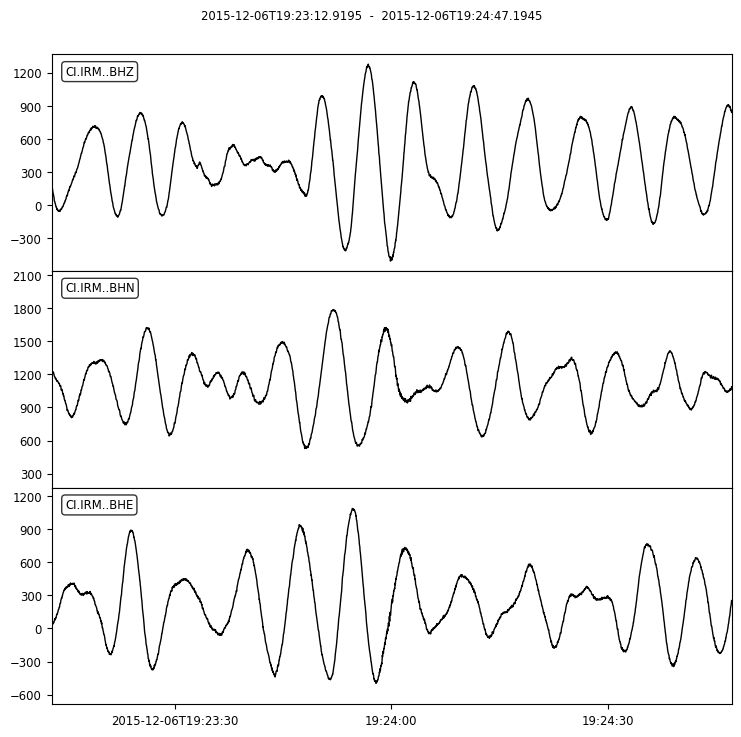

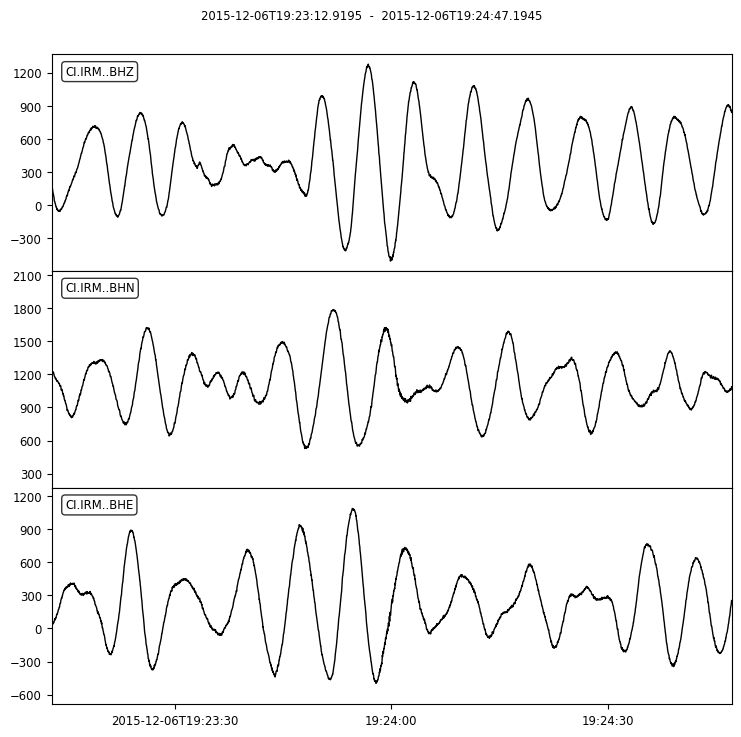

In [41]:
streams[0].plot()

# Section 3. use pre-trained PhaseNet to annotate the 16 streams

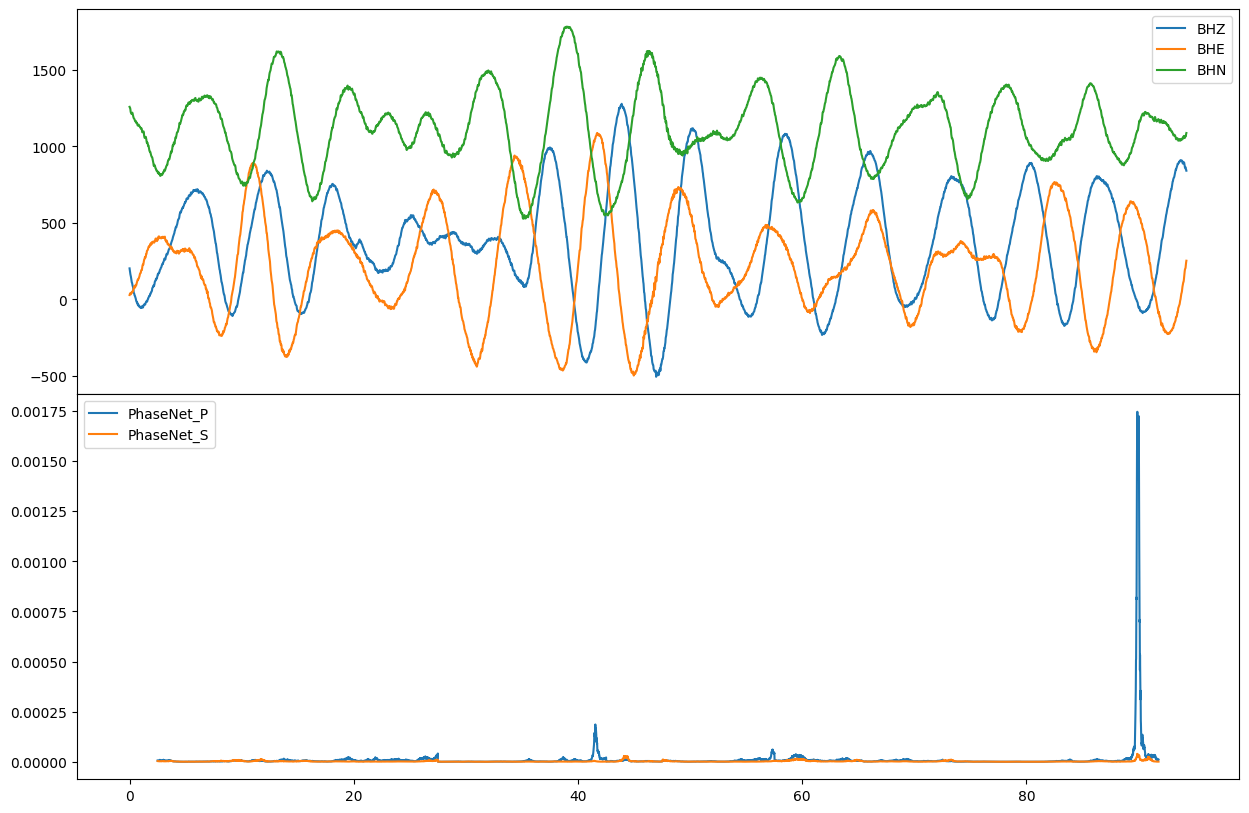

In [50]:
import seisbench.models as sbm
model = sbm.PhaseNet.from_pretrained("original")

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
import matplotlib.pyplot as plt

def plot(annotations):
    fig = plt.figure(figsize=(15, 10))
    axs = fig.subplots(2, 1, sharex=True, gridspec_kw={'hspace': 0})
    
    offset = annotations[0].stats.starttime - stream[0].stats.starttime
    for i in range(3):
        axs[0].plot(stream[i].times(), stream[i].data, label=stream[i].stats.channel)
        if annotations[i].stats.channel[-1] != "N":  # Do not plot noise curve
            axs[1].plot(annotations[i].times() + offset, annotations[i].data, label=annotations[i].stats.channel)
    
    axs[0].legend()
    axs[1].legend()

stream = streams[0]
annotations = model.annotate(stream)
plot(annotations)

In [52]:
type(annotations)

obspy.core.stream.Stream

In [57]:
import numpy as np

def is_over_threshold(data, threshold):
    indices = np.where(data >= threshold)[0]
    if indices.size > threshold:
        return 1
    return 0

over_dot_1 = 0
over_dot_5 = 0
over_dot_6 = 0

for stream in streams:
    # see if there is an annotation with high confidence in all streams
    pred_st = model.annotate(stream)
    
    for tr in pred_st:
        if tr.stats.channel == "PhaseNet_P":
            trace = tr
            break
    assert trace is not None
    data = trace.data

    # Step 2: Find all the index with probability value greater than the threshold
    over_dot_1 += is_over_threshold(data, 0.1)
    over_dot_5 += is_over_threshold(data, 0.5)
    over_dot_6 += is_over_threshold(data, 0.6)

print("Over {} streams, {} has p wave arrival pick confidence over {}".format(len(streams), over_dot_1, 0.1))
print("Over {} streams, {} has p wave arrival pick confidence over {}".format(len(streams), over_dot_5, 0.5))
print("Over {} streams, {} has p wave arrival pick confidence over {}".format(len(streams), over_dot_6, 0.6))

Over 16 streams, 6 has p wave arrival pick confidence over 0.1
Over 16 streams, 2 has p wave arrival pick confidence over 0.5
Over 16 streams, 1 has p wave arrival pick confidence over 0.6


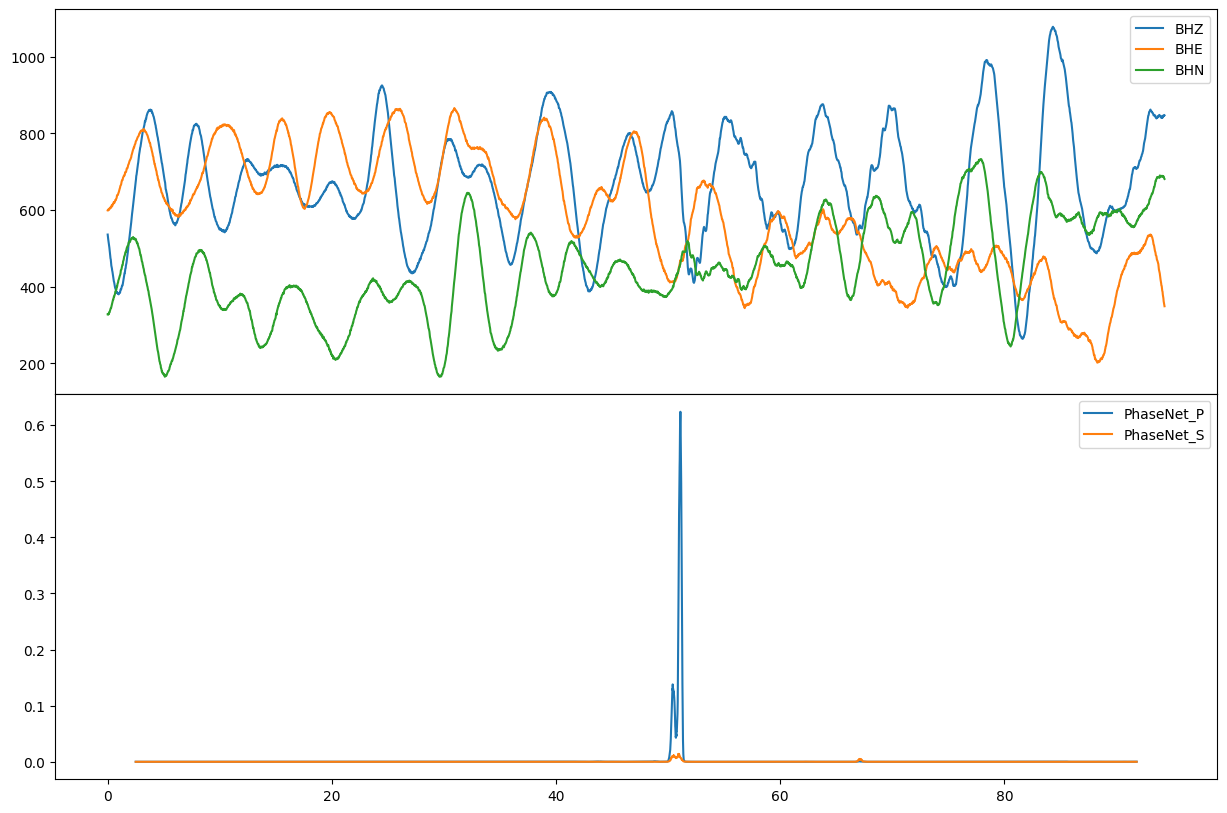

In [59]:
stream_with_highest_prob = None

for stream in streams:
    # see if there is an annotation with high confidence in all streams
    pred_st = model.annotate(stream)
    
    for tr in pred_st:
        if tr.stats.channel == "PhaseNet_P":
            trace = tr
            break
    assert trace is not None
    data = trace.data

    if is_over_threshold(data, 0.6):
        plot(pred_st)
        stream_with_highest_prob = pred_st
        break

In [64]:
tr = stream[0]

In [75]:
from mspasspy.util.converter import Trace2TimeSeries

ts = Trace2TimeSeries(stream[0])
ts['sta']
ts['chan']

'BHZ'

In [76]:
doc = db.wf_miniseed.find_one({
    "sta":       ts['sta'],
    "starttime": ts['starttime'],
    "endtime":   ts['endtime'],
    "dfile":     ts['dfile'],
    "chan":      ts['chan']
})
assert doc is not None

In [77]:
doc

{'_id': ObjectId('67fd2339b81efdb2a866fe83'),
 'sta': 'GMR',
 'net': 'CI',
 'chan': 'BHZ',
 'sampling_rate': 40.0,
 'delta': 0.025,
 'starttime': 1451286979.9195,
 'last_packet_time': 1451286979.9195,
 'foff': 89632768,
 'nbytes': 4096,
 'npts': 3772,
 'endtime': 1451287074.1945002,
 'storage_mode': 'file',
 'format': 'mseed',
 'dir': '/scratch1/07114/jiaoma/usarray_2015/2015',
 'dfile': '/scratch1/07114/jiaoma/usarray_2015/2015/event7.mseed',
 'time_standard': 'UTC',
 'manual_picks': [1451287029.41132]}

In [78]:
doc["manual_picks"]

[1451287029.41132]

# Important Plot. PhaseNet model pick vs manual pick (read vertical dotted line is manual pick)

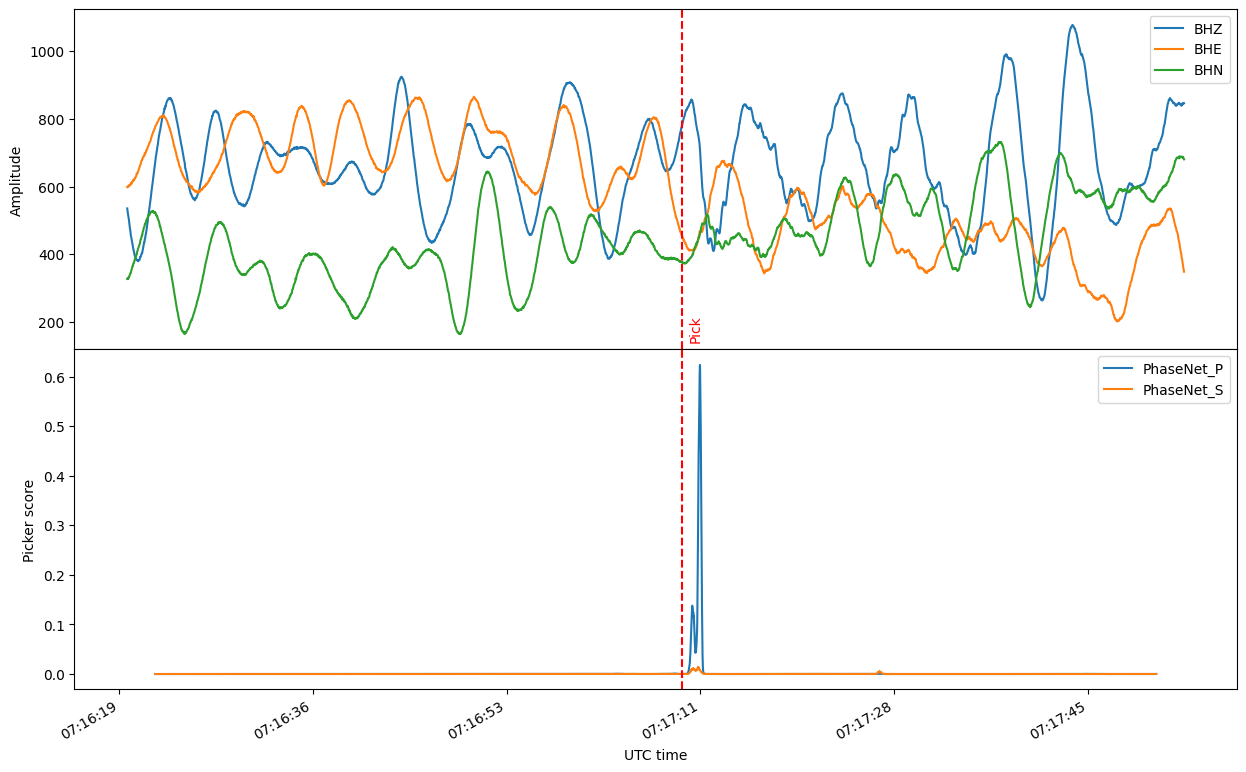

In [83]:
from matplotlib.dates import date2num
from obspy import UTCDateTime
import matplotlib.dates as mdates

def plot(stream, annotations, highlight_time=None):
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(15, 10),
                            gridspec_kw={'hspace': 0})

    st0_mpl = stream[0].stats.starttime.matplotlib_date  # scalar
    to_mpl  = lambda secs: st0_mpl + secs / 86400.0      # vector-safe

    # Waveforms
    for tr in stream:
        axs[0].plot(to_mpl(tr.times()), tr.data, label=tr.stats.channel)

    # Annotation curves
    offset = annotations[0].stats.starttime - stream[0].stats.starttime
    for tr in annotations:
        if tr.stats.channel[-1] == "N":
            continue
        axs[1].plot(to_mpl(tr.times() + offset), tr.data, label=tr.stats.channel)

    # --------------------  highlight  --------------------
    if highlight_time:
        x = date2num(highlight_time.datetime)
        for ax in axs:
            ax.axvline(x, color='red', ls='--', lw=1.5)
        axs[0].annotate("Pick", xy=(x, 0), xycoords=('data', 'axes fraction'),
                        xytext=(5, 5), textcoords='offset points',
                        color='red', rotation=90, va='bottom')

    # Cosmetics
    axs[0].legend(); axs[1].legend()
    axs[0].set_ylabel('Amplitude'); axs[1].set_ylabel('Picker score')
    axs[1].set_xlabel('UTC time')
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    fig.autofmt_xdate(); plt.show()

# ---------------- usage -----------------

p_pick = UTCDateTime(doc["manual_picks"][0])

plot(stream, stream_with_highest_prob,
     highlight_time=p_pick)

In [84]:
p_pick

2015-12-28T07:17:09.411320Z